<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/Transfer_Learning_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Food101 model paper : https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf

Our baseline to beat is 50.76% accuracy across 101 classes.

In [4]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-05-27 03:19:17--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-27 03:19:17 (26.0 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [5]:
import pandas as pd
import sklearn as sk
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data,compare_historys, walk_through_dir

In [10]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
unzip_data("101_food_classes_10_percent.zip")

--2026-05-27 03:20:17--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.142.207, 74.125.195.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.142.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  72.2MB/s    in 14s     

2026-05-27 03:20:32 (107 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [11]:
train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [12]:
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pulled_pork_sandwich'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pancakes'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/lobster_roll_sandwich'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/edamame'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/sashimi'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/apple_pie'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/nachos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/bruschetta'.
There are 0 directories and 75 images 

In [13]:
import tensorflow as tf
IMG_SIZE = (224,224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical")
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical",
                                                                            shuffle=False)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


# Train a big dog model with transfer learning on 10% of 101 food classes

In [ ]:
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
    # layers.Rescaling(1/255.),
], name="data_augmentation")

In [ ]:
from numpy._core.fromnumeric import shape
# Setting up base model and freeze its layers (which will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool_layer")(x)
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax",
                       name="output_layer")(x)
model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool_layer           │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5,validation_data=test_data,
                                           validation_steps = int(0.25*len(test_data)),
                                           callbacks = [checkpoint_callback])

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.2657 - loss: 3.4186 - val_accuracy: 0.3883 - val_loss: 2.6350
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.4818 - loss: 2.2619 - val_accuracy: 0.4668 - val_loss: 2.1520
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.5483 - loss: 1.8928 - val_accuracy: 0.4948 - val_loss: 1.9747
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 188ms/step - accuracy: 0.5904 - loss: 1.6770 - val_accuracy: 0.5206 - val_loss: 1.8350
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 81s 342ms/step - accuracy: 0.6187 - loss: 1.5360 - val_accuracy: 0.5187 - val_loss: 1.8082


In [ ]:
fine_tuning_results = model.evaluate(test_data)
fine_tuning_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.5711 - loss: 1.6115


[1.6115353107452393, 0.5711287260055542]

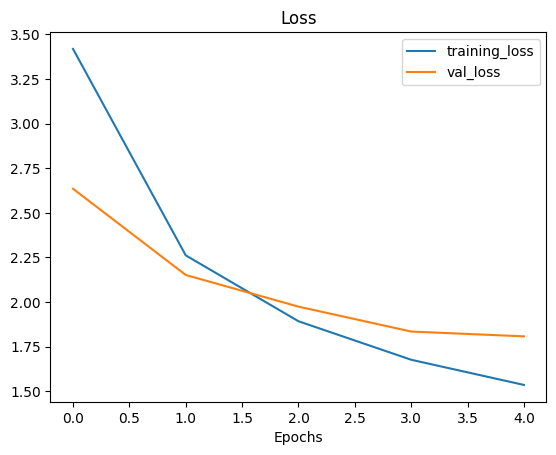

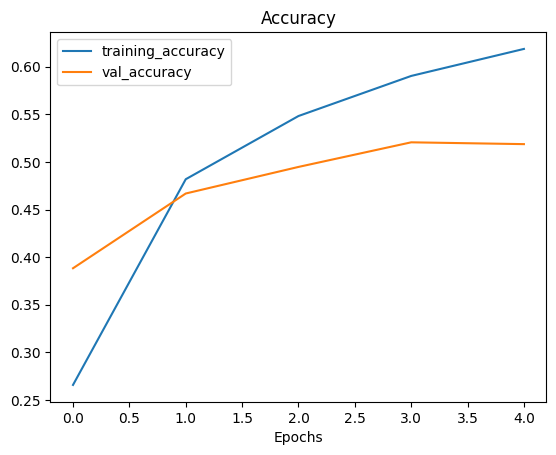

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(history_all_classes_10_percent)

# Fine Tuning

In [ ]:
# unfreeze all of the layers in the base model
base_model.trainable = True

In [ ]:
# Refreeze every layer except the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [ ]:
# Lowering the learning rate
model.compile(loss="categorical_crossentropy",
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics = ["accuracy"])

In [ ]:
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_avg_pool_layer True
output_layer True


In [ ]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [ ]:
fine_tune_epochs = 10

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs = fine_tune_epochs,
                                                     validation_data = test_data,
                                                     validation_steps= int(0.15* len(test_data)),
                                                     initial_epoch = history_all_classes_10_percent.epoch[-1])

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accuracy: 0.6448 - loss: 1.4648 - val_accuracy: 0.5609 - val_loss: 1.7038
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.6793 - loss: 1.3163 - val_accuracy: 0.5678 - val_loss: 1.6631
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 77s 159ms/step - accuracy: 0.6964 - loss: 1.2333 - val_accuracy: 0.5710 - val_loss: 1.6381
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.7073 - loss: 1.1856 - val_accuracy: 0.5773 - val_loss: 1.6104
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 172ms/step - accuracy: 0.7282 - loss: 1.1079 - val_accuracy: 0.5821 - val_loss: 1.5910
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.7411 - loss: 1.0612 - val_accuracy: 0.5855 - val_loss: 1.5794


### Evaluating on whole test data

In [ ]:
all_classes_10_percent_fine_tune_results= model.evaluate(test_data)
all_classes_10_percent_fine_tune_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 63s 79ms/step - accuracy: 0.6176 - loss: 1.4249


[1.424851655960083, 0.6176237463951111]

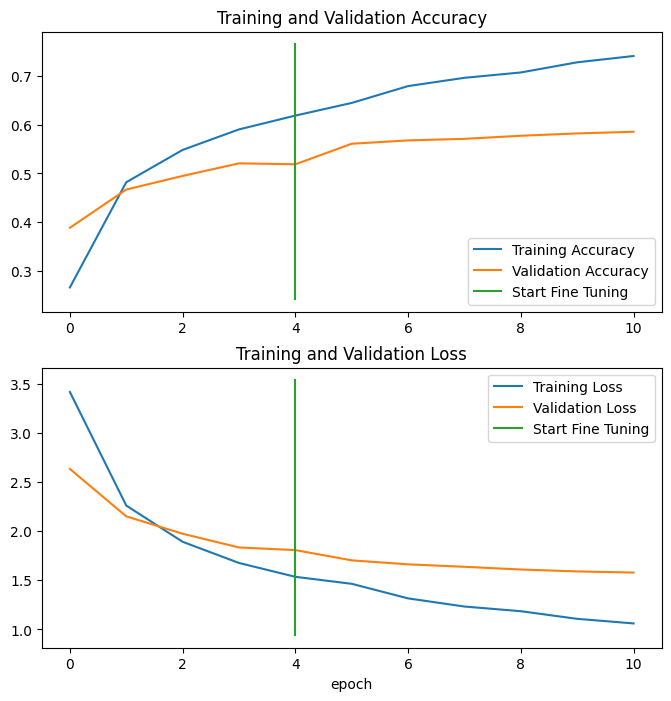

In [ ]:
# Comapring histories
compare_historys(history_all_classes_10_percent,
                 history_all_classes_10_percent_fine_tune,
                 initial_epochs = 5)

# Saving our model

In [ ]:
model.save("drive/MyDrive/Colab Notebooks/Food Vision/efficientnetb0_fine_tuned_101_classes_10_percent.keras")

In [2]:
import tensorflow as tf
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Food Vision/efficientnetb0_fine_tuned_101_classes_10_percent.keras")

In [14]:
loaded_model_results = loaded_model.evaluate(test_data)
loaded_model_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 73s 81ms/step - accuracy: 0.6176 - loss: 1.4249


[1.424851655960083, 0.6176237463951111]

In [ ]:
all_classes_10_percent_fine_tune_results

[1.424851655960083, 0.6176237463951111]

# Loading and evaluating our model

In [15]:
import tensorflow as tf
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip

--2026-05-27 03:23:35--  https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46760742 (45M) [application/zip]
Saving to: ‘06_101_food_class_10_percent_saved_big_dog_model.zip’

06_101_food_class_1 100%[===================>]  44.59M   110MB/s    in 0.4s    

2026-05-27 03:23:35 (110 MB/s) - ‘06_101_food_class_10_percent_saved_big_dog_model.zip’ saved [46760742/46760742]



In [16]:
unzip_data("06_101_food_class_10_percent_saved_big_dog_model.zip")

In [18]:
model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Food Vision/efficientnetb0_fine_tuned_101_classes_10_percent.keras")

In [45]:
results_downloaded_model = model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.6176 - loss: 1.4249


# Making preds

In [21]:
preds_probs = model.predict(test_data, verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 71s 87ms/step


In [22]:
len(test_data)

790

In [24]:
790*32

25280

In [23]:
len(preds_probs)

25250

In [26]:
preds_probs.shape

(25250, 101)

In [27]:
# Looking into first 10 preds
preds_probs[:10]

array([[2.9325294e-01, 5.8192300e-04, 1.7411268e-01, ..., 1.4519127e-04,
        3.5911293e-03, 1.7448358e-02],
       [8.9445674e-01, 2.2826015e-07, 2.2796041e-03, ..., 4.4061057e-03,
        2.4681926e-06, 2.8572198e-05],
       [3.5576305e-01, 1.8931864e-02, 5.8308728e-03, ..., 1.5712073e-03,
        1.5949347e-03, 2.9224916e-03],
       ...,
       [3.6489806e-01, 2.9107678e-06, 1.8249732e-03, ..., 1.3459204e-01,
        3.4421909e-04, 3.5410887e-04],
       [1.1839766e-01, 3.5667350e-04, 2.3988321e-01, ..., 7.1582664e-04,
        3.7004374e-04, 3.5846446e-04],
       [6.6212147e-01, 5.4746224e-06, 3.0468507e-03, ..., 2.7145296e-03,
        1.5570304e-05, 6.7820313e-04]], dtype=float32)

In [28]:
preds_probs[0]

array([2.93252945e-01, 5.81922999e-04, 1.74112678e-01, 8.08594507e-07,
       3.08913768e-05, 2.62338781e-05, 2.07933888e-04, 7.14483103e-05,
       3.96243706e-02, 5.54334081e-04, 7.29581461e-06, 1.98082998e-05,
       2.48457701e-03, 2.72923808e-06, 1.74752269e-02, 2.12243502e-03,
       9.19927188e-05, 1.78305840e-03, 1.03193959e-02, 2.29427114e-05,
       1.00623502e-03, 1.04610670e-04, 2.23474519e-04, 3.60995822e-04,
       1.98222767e-03, 4.82633803e-03, 3.19921738e-03, 1.33394889e-04,
       1.00466445e-01, 3.06002772e-03, 2.93621197e-05, 1.72080856e-03,
       4.61244286e-04, 5.44110699e-05, 3.72024463e-03, 1.31772040e-05,
       5.56363841e-04, 3.47254192e-03, 2.53501106e-02, 2.67713185e-04,
       5.57287072e-04, 7.10989581e-03, 5.80239459e-04, 5.82542125e-05,
       7.84522912e-04, 1.51801083e-04, 3.64992209e-03, 1.86903169e-04,
       1.64558969e-05, 2.84836702e-02, 1.84951074e-04, 1.46663035e-04,
       7.55313933e-02, 1.17705017e-02, 1.21388650e-04, 2.57174429e-02,
      

In [29]:
len(preds_probs[0])

101

In [30]:
sum(preds_probs[0])

np.float32(1.0000001)

In [31]:
sum(preds_probs[98])

np.float32(1.0000002)

In [32]:
preds_probs[0].argmax()

np.int64(0)

In [33]:
test_data.class_names[0]

'apple_pie'

In [34]:
preds_probs[98].argmax(), test_data.class_names[98]

(np.int64(59), 'tiramisu')

In [35]:
pred_classes = preds_probs.argmax(axis=1)
pred_classes[:10]

array([ 0,  0,  0,  0,  8, 78, 29,  0,  9,  0])

In [36]:
# Getting our test labels by unraveling our test_data BatchDataset
y_labels = []
for images, labels in test_data.unbatch():
  y_labels.append(labels.numpy().argmax())

In [41]:
len(y_labels)

25250

# Evaluating

In [44]:
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_labels, pred_classes)
sklearn_accuracy

0.6176237623762376

In [46]:
import numpy as np
np.isclose(results_downloaded_model[1], sklearn_accuracy)

np.True_

In [47]:
from helper_functions import make_confusion_matrix

In [48]:
class_names = test_data.class_names
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [55]:
make_confusion_matrix(y_labels, pred_classes,
                      class_names, figsize=(100,100), text_size = 20,
                      savefig=True)

In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.33      0.24      0.28       250
           1       0.57      0.72      0.63       250
           2       0.67      0.66      0.67       250
           3       0.82      0.52      0.64       250
           4       0.58      0.48      0.52       250
           5       0.46      0.45      0.46       250
           6       0.72      0.80      0.76       250
           7       0.85      0.73      0.79       250
           8       0.26      0.60      0.36       250
           9       0.38      0.72      0.49       250
          10       0.55      0.40      0.47       250
          11       0.76      0.64      0.70       250
          12       0.75      0.59      0.66       250
          13       0.58      0.57      0.58       250
          14       0.49      0.68      0.57       250
          15       0.43      0.39      0.41       250
          16       0.71      0.54      0.61       250
          17       0.35    